<a href="https://colab.research.google.com/github/himanshisangani64-beep/numpy_all_code/blob/main/Summarize%2C_Visualize%2C_Merge_and_Join_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Sorting and Filtering Data

1.1 Load a dataset (e.g., Titanic or any CSV) into a DataFrame.

In [1]:
import pandas as pd

df=pd.read_csv('/content/titanic.csv')
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [2]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [3]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [4]:
df['age'] = df['age'].fillna(df['age'].mean())

In [5]:
df['deck'] = df['deck'].fillna('unknow')

In [6]:
df['embarked'] = df['embarked'].fillna('unknow')


In [7]:
df['embark_town'] = df['embark_town'].fillna('unknow')

In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [9]:
df.sort_values(by=["age", "fare"], ascending=False, inplace=True)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80.00,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
851,0,3,male,74.00,0,0,7.7750,S,Third,man,True,unknow,Southampton,no,True
493,0,1,male,71.00,0,0,49.5042,C,First,man,True,unknow,Cherbourg,no,True
96,0,1,male,71.00,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.50,0,0,7.7500,Q,Third,man,True,unknow,Queenstown,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,unknow,Southampton,yes,False
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,unknow,Cherbourg,yes,False
644,1,3,female,0.75,2,1,19.2583,C,Third,child,False,unknow,Cherbourg,yes,False
755,1,2,male,0.67,1,1,14.5000,S,Second,child,False,unknow,Southampton,yes,False


In [10]:
df['age'] = df['age'].astype(dtype=int)

In [11]:
df.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80,0,0,30.0,S,First,man,True,A,Southampton,yes,True


In [12]:
df[df['age']>30].tail(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
749,0,3,male,31,0,0,7.75,Q,Third,man,True,unknow,Queenstown,no,True


Task 2: Aggregation and Grouping

In [13]:
df.groupby("class")["sex"].value_counts()

class   sex   
First   male      122
        female     94
Second  male      108
        female     76
Third   male      347
        female    144
Name: count, dtype: int64

In [14]:
df.groupby("class")["sex"].count()

,sex
class,
First,216
Second,184
Third,491


In [15]:
import numpy as np
df["Gender"] = np.where(df['sex']=="male",0,1)

In [16]:
class_gender_sum = df.groupby("class")['Gender'].sum()
class_gender_sum

,Gender
class,
First,94
Second,76
Third,144


In [17]:
class_gender_mean = df.groupby("class")['Gender'].mean()
class_gender_mean

,Gender
class,
First,0.435185
Second,0.413043
Third,0.293279


In [18]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Gender
630,1,1,male,80,0,0,30.000,S,First,man,True,A,Southampton,yes,True,0
851,0,3,male,74,0,0,7.775,S,Third,man,True,unknow,Southampton,no,True,0


In [19]:
df['pclass'].value_counts()

,count
pclass,
3,491
1,216
2,184


Task 3: Data Visualization

<Axes: xlabel='class'>

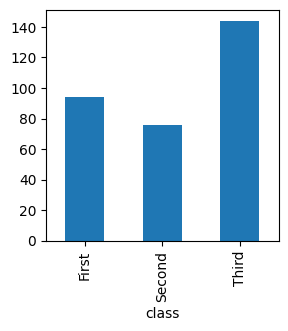

In [20]:
class_gender_sum.plot(kind="bar",figsize=(3,3))

In [21]:
c = df['embarked'].value_counts()

<Axes: ylabel='count'>

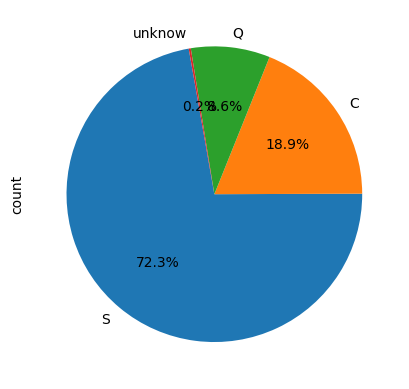

In [22]:
c.plot(kind="pie",autopct="%1.1f%%",startangle=100)

<Axes: xlabel='age', ylabel='fare'>

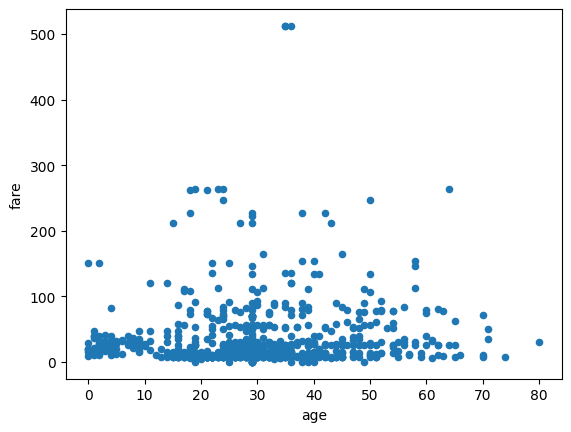

In [23]:
df.plot(kind="scatter",x="age",y="fare")

Task 4: Merging DataFrames

In [24]:
Emp1 = pd.DataFrame({
    "empid":[1,2,3,4,5,6,7,8,9,10],
    "name":["A","B","C","D","E","F","G","H","I",np.nan]
})
Emp1

,empid,name
0,1,A
1,2,B
2,3,C
3,4,D
4,5,E
5,6,F
6,7,G
7,8,H
8,9,I
9,10,NaN


In [25]:
Emp2 = pd.DataFrame({
    "empid":[1,2,3,4,5,6,7,5,9,10],
    "salary":[10000,12000,40000,30000,40000,70000,23000,56000,78000,24000]
})
Emp2

,empid,salary
0,1,10000
1,2,12000
2,3,40000
3,4,30000
4,5,40000
5,6,70000
6,7,23000
7,5,56000
8,9,78000
9,10,24000


In [26]:
Emp1.merge(Emp2,how="inner",on="empid")

,empid,name,salary
0,1,A,10000
1,2,B,12000
2,3,C,40000
3,4,D,30000
4,5,E,40000
5,5,E,56000
6,6,F,70000
7,7,G,23000
8,9,I,78000
9,10,NaN,24000


In [27]:
Emp1.merge(Emp2,how="outer",on="empid")

,empid,name,salary
0,1,A,10000.0
1,2,B,12000.0
2,3,C,40000.0
3,4,D,30000.0
4,5,E,40000.0
5,5,E,56000.0
6,6,F,70000.0
7,7,G,23000.0
8,8,H,NaN
9,9,I,78000.0


Task 5: Joining DataFrames

In [28]:
std = pd.DataFrame(
    {
        "stdid":[1,2,3,4,5,6,7,8,9],
        "grads":['A','A','B','C','D','B','C','D','C']
    }
)
std

,stdid,grads
0,1,A
1,2,A
2,3,B
3,4,C
4,5,D
5,6,B
6,7,C
7,8,D
8,9,C


In [29]:
std1 = pd.DataFrame(
    {
        "stdid":[1,2,3,4,5,6,8,1,2],
        "Activities":['Playing','Reading','Writeing','Sleeping','Eating',"Playing","Reading","Sleeping","Writeing"]
    }
)
std1

,stdid,Activities
0,1,Playing
1,2,Reading
2,3,Writeing
3,4,Sleeping
4,5,Eating
5,6,Playing
6,8,Reading
7,1,Sleeping
8,2,Writeing


In [30]:
std.merge(std1,how="left",on="stdid")

,stdid,grads,Activities
0,1,A,Playing
1,1,A,Sleeping
2,2,A,Reading
3,2,A,Writeing
4,3,B,Writeing
5,4,C,Sleeping
6,5,D,Eating
7,6,B,Playing
8,7,C,NaN
9,8,D,Reading


In [31]:
std.merge(std1,how="right",on="stdid")

,stdid,grads,Activities
0,1,A,Playing
1,2,A,Reading
2,3,B,Writeing
3,4,C,Sleeping
4,5,D,Eating
5,6,B,Playing
6,8,D,Reading
7,1,A,Sleeping
8,2,A,Writeing


Task 6: Complex Merging

In [32]:
cus_data = {
    "cid":[1,2,3,4,5,6,7,8,9,10],
    "name":["A","B","C","D","E","F","G","H","I","J"]

  }
d = pd.DataFrame(cus_data)
d

,cid,name
0,1,A
1,2,B
2,3,C
3,4,D
4,5,E
5,6,F
6,7,G
7,8,H
8,9,I
9,10,J


In [33]:
ord_data = {
    "oid":[11,12,13,14,15,16,17,18,19,20],
    "cid":[1,2,3,4,5,3,7,8,9,1],
    "Date":["01-01-2025","02-01-2025","02-02-2026","05-02-2026","10-02-2026","11-02-2026","01-03-2026","05-03-2026","15-03-2026","22-03-2026"],
    "price":[10000,200,30000,1000,1500,16000,3000,700,93000,13000]

  }
d1 = pd.DataFrame(ord_data)
d1

,oid,cid,Date,price
0,11,1,01-01-2025,10000
1,12,2,02-01-2025,200
2,13,3,02-02-2026,30000
3,14,4,05-02-2026,1000
4,15,5,10-02-2026,1500
5,16,3,11-02-2026,16000
6,17,7,01-03-2026,3000
7,18,8,05-03-2026,700
8,19,9,15-03-2026,93000
9,20,1,22-03-2026,13000


In [34]:
res = pd.merge(d,d1,on="cid")
res

,cid,name,oid,Date,price
0,1,A,11,01-01-2025,10000
1,1,A,20,22-03-2026,13000
2,2,B,12,02-01-2025,200
3,3,C,13,02-02-2026,30000
4,3,C,16,11-02-2026,16000
5,4,D,14,05-02-2026,1000
6,5,E,15,10-02-2026,1500
7,7,G,17,01-03-2026,3000
8,8,H,18,05-03-2026,700
9,9,I,19,15-03-2026,93000


In [35]:
res[res['price']>1000]

,cid,name,oid,Date,price
0,1,A,11,01-01-2025,10000
1,1,A,20,22-03-2026,13000
3,3,C,13,02-02-2026,30000
4,3,C,16,11-02-2026,16000
6,5,E,15,10-02-2026,1500
7,7,G,17,01-03-2026,3000
9,9,I,19,15-03-2026,93000


Task 7: Advanced Aggregation

In [36]:
res['Dates'] = pd.to_datetime(res['Date'],format="%d-%m-%Y")

In [37]:
res

,cid,name,oid,Date,price,Dates
0,1,A,11,01-01-2025,10000,2025-01-01
1,1,A,20,22-03-2026,13000,2026-03-22
2,2,B,12,02-01-2025,200,2025-01-02
3,3,C,13,02-02-2026,30000,2026-02-02
4,3,C,16,11-02-2026,16000,2026-02-11
5,4,D,14,05-02-2026,1000,2026-02-05
6,5,E,15,10-02-2026,1500,2026-02-10
7,7,G,17,01-03-2026,3000,2026-03-01
8,8,H,18,05-03-2026,700,2026-03-05
9,9,I,19,15-03-2026,93000,2026-03-15


In [38]:
res["Month"]=res['Dates'].dt.month

In [39]:
res["year"]=res['Dates'].dt.year

In [40]:
res

,cid,name,oid,Date,price,Dates,Month,year
0,1,A,11,01-01-2025,10000,2025-01-01,1,2025
1,1,A,20,22-03-2026,13000,2026-03-22,3,2026
2,2,B,12,02-01-2025,200,2025-01-02,1,2025
3,3,C,13,02-02-2026,30000,2026-02-02,2,2026
4,3,C,16,11-02-2026,16000,2026-02-11,2,2026
5,4,D,14,05-02-2026,1000,2026-02-05,2,2026
6,5,E,15,10-02-2026,1500,2026-02-10,2,2026
7,7,G,17,01-03-2026,3000,2026-03-01,3,2026
8,8,H,18,05-03-2026,700,2026-03-05,3,2026
9,9,I,19,15-03-2026,93000,2026-03-15,3,2026


In [41]:
res["days"]=res['Dates'].dt.day

In [42]:
res

,cid,name,oid,Date,price,Dates,Month,year,days
0,1,A,11,01-01-2025,10000,2025-01-01,1,2025,1
1,1,A,20,22-03-2026,13000,2026-03-22,3,2026,22
2,2,B,12,02-01-2025,200,2025-01-02,1,2025,2
3,3,C,13,02-02-2026,30000,2026-02-02,2,2026,2
4,3,C,16,11-02-2026,16000,2026-02-11,2,2026,11
5,4,D,14,05-02-2026,1000,2026-02-05,2,2026,5
6,5,E,15,10-02-2026,1500,2026-02-10,2,2026,10
7,7,G,17,01-03-2026,3000,2026-03-01,3,2026,1
8,8,H,18,05-03-2026,700,2026-03-05,3,2026,5
9,9,I,19,15-03-2026,93000,2026-03-15,3,2026,15


In [43]:
month = res.groupby("Month")["oid"].count()
month

,oid
Month,
1,2
2,4
3,4


In [44]:
revenu = res.groupby("Month")["price"].mean()
revenu

,price
Month,
1,5100.0
2,12125.0
3,27425.0


<Axes: xlabel='Month'>

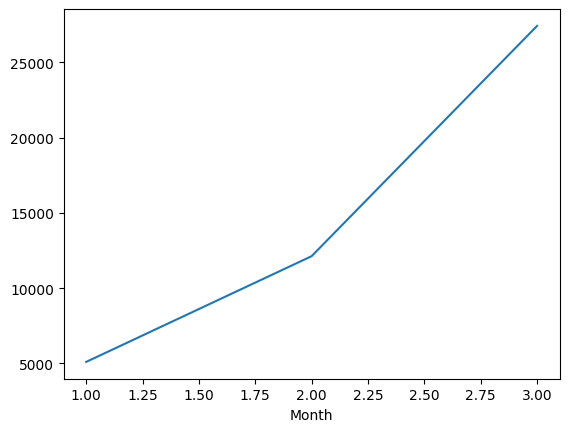

In [45]:
revenu.plot(kind="line")

Task 8: Challenge Task

In [130]:
p = pd.read_csv("/content/product.csv")
p.head(1)

s = pd.read_csv("/content/sales.csv")
s.head(1)

re = pd.read_csv("/content/return.csv")
re.head(1)

,return_id,sale_id,product_id,return_quantity,return_date
0,2001,1042,21,4,2023-01-15


In [134]:
product_sales = pd.merge(p,s,how="inner",on="product_id")
product_sales.head(1)

product_sales["Total_Sales"] = product_sales['quantity']*product_sales['unit_price']
product_sales.head(1)

,product_id,product_name,category,unit_price,sale_id,quantity,sale_date,Total_Sales
0,2,Product_2,Electronics,136.21,1013,1,2023-01-13,136.21


In [142]:
retuen_sales = pd.merge(p,re,how="inner",on="product_id")
retuen_sales.head(2)

retuen_sales["return_Sales_data"] =retuen_sales['return_quantity'] * retuen_sales['unit_price']
retuen_sales.head(2)

TotalSales = product_sales['Total_Sales'].sum()
TotalReturn = retuen_sales['return_Sales_data'].sum()

NetSales = TotalSales-TotalReturn
NetSales

np.float64(96386.27999999998)

In [140]:
sales_View = {"Sales":[TotalSales],"Return":[TotalReturn],}
sales = pd.DataFrame(sales_View)
sales


,Sales,Return
0,167157.05,70770.77


<Axes: >

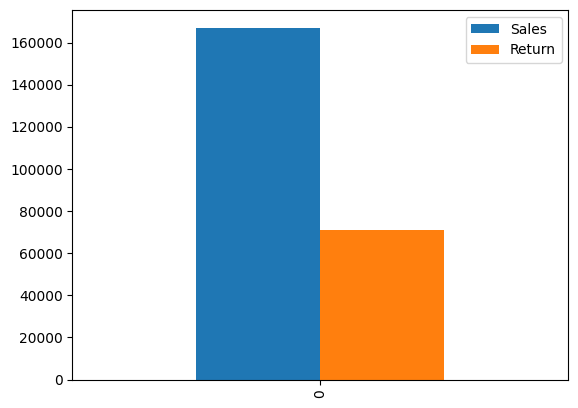

In [145]:

sales.plot(kind="bar")

In [146]:

total = product_sales['Total_Sales']-retuen_sales['return_Sales_data']
total.head(2)

,0
0,-408.63
1,-2434.90


In [162]:

product_Total_Sles1 = {
    "Product Name":retuen_sales['product_name'],
    "NetSales":total
}
product_per_sales1 = pd.DataFrame(product_Total_Sles1)
product_per_sales1.head(1)

,Product Name,NetSales
0,Product_2,-408.63


<Axes: >

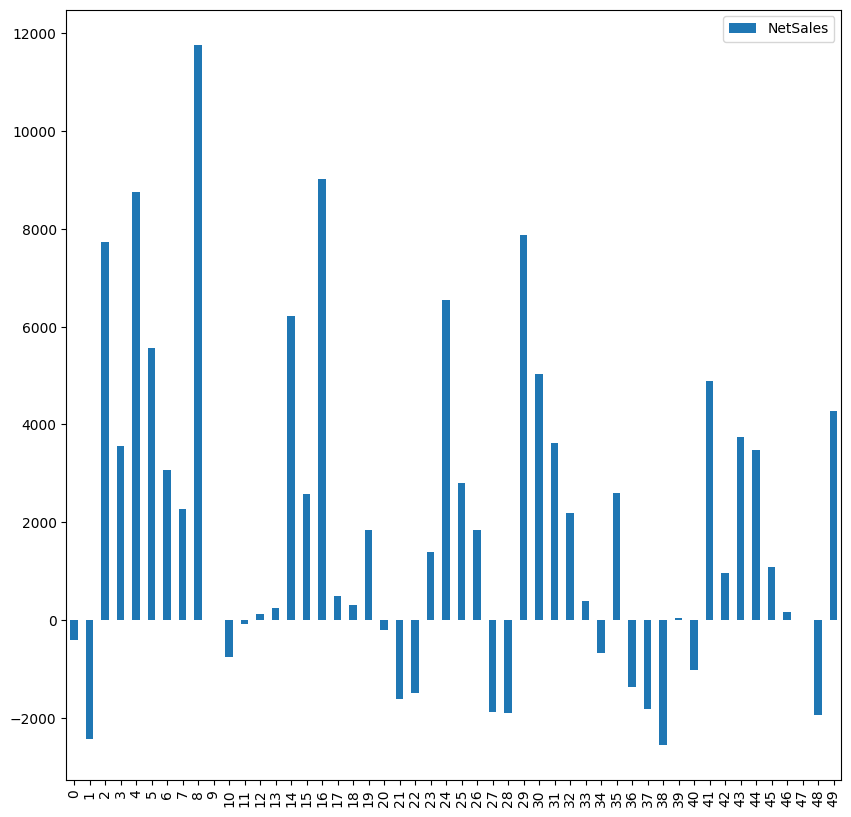

In [161]:
product_per_sales1.plot(kind="bar",figsize=(10,10))